# Job Recommendations: Do Better Features Beat a Better Title Match?

A content-based "similar jobs" recommender built on **2,800 live tech postings from 119 US and
Canadian companies**, comparing two models head to head:

| | Model | What it sees |
|---|---|---|
| **A** | Baseline | Job **title** only (TF-IDF cosine similarity) |
| **B** | Enhanced | Description + title + job family + seniority + location + workplace type + employment type |

**Data source.** A single XML feed assembled from the public ATS job boards of named tech
companies — Greenhouse, Lever and Ashby. `fetch_feed.py` in this directory builds it.

Why not an off-the-shelf aggregate feed? The big ones (e.g. Workable's 177K-job board feed)
are dominated by non-tech roles outside North America, and none of them carry a trustworthy
remote / hybrid / on-site signal. Ashby and Lever expose `workplaceType` directly, so the feed
we build here has a real workplace mix instead of a guessed one.

**Output.** Three JSON files consumed by the Next.js app in `../web`, which shows both models'
recommendations side by side for any job.

## 1. Setup

In [1]:
# Google Colab: uncomment to install dependencies
# !pip install -q lxml beautifulsoup4 scikit-learn pandas numpy matplotlib seaborn tqdm requests

import gzip
import json
import os
import re
import shutil
import textwrap
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from lxml import etree
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

XML_PATH = "data/tech_jobs_feed.xml"
GZ_PATH = XML_PATH + ".gz"
FEED_URL = (
    "https://raw.githubusercontent.com/jimmymarsanico/job-rec-demo/"
    "main/notebook/data/tech_jobs_feed.xml.gz"
)
OUTPUT_DIR = "output"
SAMPLE_SIZE = 1000
TOP_N = 3
SEED = 42

os.makedirs("data", exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(SEED)

BLUE, GREEN, PURPLE = "#3b82f6", "#10b981", "#8b5cf6"
print("Setup complete.")

/Users/jimmymarsanico/.claude/jobs/24cf9207/tmp/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Setup complete.


## 2. Get the feed

The feed is committed to the repo gzipped (3.4 MB), so this notebook runs from a cold start on
Colab without hitting 120+ ATS endpoints. To rebuild it from live job boards instead, run
`python fetch_feed.py --gzip`.

In [2]:
if os.path.exists(XML_PATH):
    print(f"Using cached feed: {XML_PATH} ({os.path.getsize(XML_PATH) / 1e6:.1f} MB)")
else:
    if not os.path.exists(GZ_PATH):
        print(f"Downloading {FEED_URL} ...")
        r = requests.get(FEED_URL, timeout=300)
        r.raise_for_status()
        with open(GZ_PATH, "wb") as f:
            f.write(r.content)
        print(f"  saved {GZ_PATH} ({os.path.getsize(GZ_PATH) / 1e6:.1f} MB)")
    print(f"Decompressing {GZ_PATH} ...")
    with gzip.open(GZ_PATH, "rb") as fi, open(XML_PATH, "wb") as fo:
        shutil.copyfileobj(fi, fo)
    print(f"  wrote {XML_PATH} ({os.path.getsize(XML_PATH) / 1e6:.1f} MB)")

Using cached feed: data/tech_jobs_feed.xml (26.7 MB)


## 3. Parse the XML feed

`lxml.etree.iterparse` streams the document and we clear each element after reading it, so memory
stays flat regardless of feed size — the same pattern scales to the 800 MB aggregate feeds.

In [3]:
FIELDS = {
    "id": "referencenumber", "title": "title", "company": "company",
    "city": "city", "state": "state", "country": "country",
    "workplace": "workplace", "job_type": "jobtype", "category": "category",
    "experience": "experience", "education": "education",
    "department": "department", "team": "team",
    "url": "url", "date": "date", "source": "feedsource",
    "description": "description",
}


def parse_feed(xml_path):
    jobs = []
    context = etree.iterparse(xml_path, events=("end",), tag="job", recover=True)
    for _, elem in context:
        job = {k: (elem.findtext(tag) or "").strip() for k, tag in FIELDS.items()}
        job["remote"] = (elem.findtext("remote") or "").strip().lower() == "true"
        if job["id"] and job["title"] and job["description"]:
            jobs.append(job)
        elem.clear()
        while elem.getprevious() is not None:
            del elem.getparent()[0]
    return jobs


all_jobs = parse_feed(XML_PATH)
df_all = pd.DataFrame(all_jobs)
print(f"Parsed {len(df_all):,} jobs from the feed")
print(f"Columns: {list(df_all.columns)}")
df_all[["title", "company", "city", "state", "workplace", "category", "experience"]].head(8)

Parsed 2,793 jobs from the feed
Columns: ['id', 'title', 'company', 'city', 'state', 'country', 'workplace', 'job_type', 'category', 'experience', 'education', 'department', 'team', 'url', 'date', 'source', 'description', 'remote']


,title,company,city,state,workplace,category,experience
0,Research Scientist (Measurement and Evaluation),Abridge,New York,NY,Hybrid,AI / ML Research,Mid level
1,"Director, Data Science",Abridge,San Francisco,CA,Hybrid,Data Science,Director
2,Senior Data Scientist,Abridge,San Francisco,CA,Hybrid,Data Science,Senior
3,Senior Research Data Scientist,Abridge,New York,NY,Hybrid,Data Science,Senior
4,"Engineering Manager, Model Inference",Abridge,San Francisco,CA,Hybrid,Engineering Management,Senior
5,"Senior Full Stack Engineer, Integrations Cerner",Abridge,Remote,Unknown,Remote,Full-Stack Engineering,Senior
6,"Senior Full Stack Engineer, Integrations Epic",Abridge,Unknown,CA,Hybrid,Full-Stack Engineering,Senior
7,"Senior Full Stack Engineer, Integrations VistA",Abridge,Remote,Unknown,Remote,Full-Stack Engineering,Senior


## 4. What is actually in the feed?

In [4]:
print(f"{len(df_all):,} postings | {df_all['company'].nunique()} companies "
      f"| {df_all['category'].nunique()} job families\n")

print("Workplace type")
print(df_all["workplace"].value_counts().to_string())
print(f"\nCountry\n{df_all['country'].value_counts().to_string()}")
print(f"\nSeniority\n{df_all['experience'].value_counts().to_string()}")
print(f"\nATS source\n{df_all['source'].value_counts().to_string()}")
print(f"\nTop 12 job families\n{df_all['category'].value_counts().head(12).to_string()}")
print(f"\nTop 12 companies\n{df_all['company'].value_counts().head(12).to_string()}")

2,793 postings | 119 companies | 19 job families

Workplace type
workplace
On-site    1354
Remote      735
Hybrid      704

Country
country
US    2484
CA     309

Seniority
experience
Senior               1144
Mid level             830
Staff / Principal     673
Director               91
Executive              27
Internship             17
Entry level            11

ATS source
source
greenhouse    1754
ashby          970
lever           69

Top 12 job families
category
Software Engineering            602
Engineering Management          337
Product Management              301
Infrastructure & DevOps         267
Machine Learning Engineering    188
Product Design                  152
AI / ML Research                151
Solutions Engineering           132
Full-Stack Engineering          125
Data Science                    116
Backend Engineering             104
Security Engineering            100

Top 12 companies
company
Zoox          45
Replit        45
Crusoe        45
Databricks    45
Ly

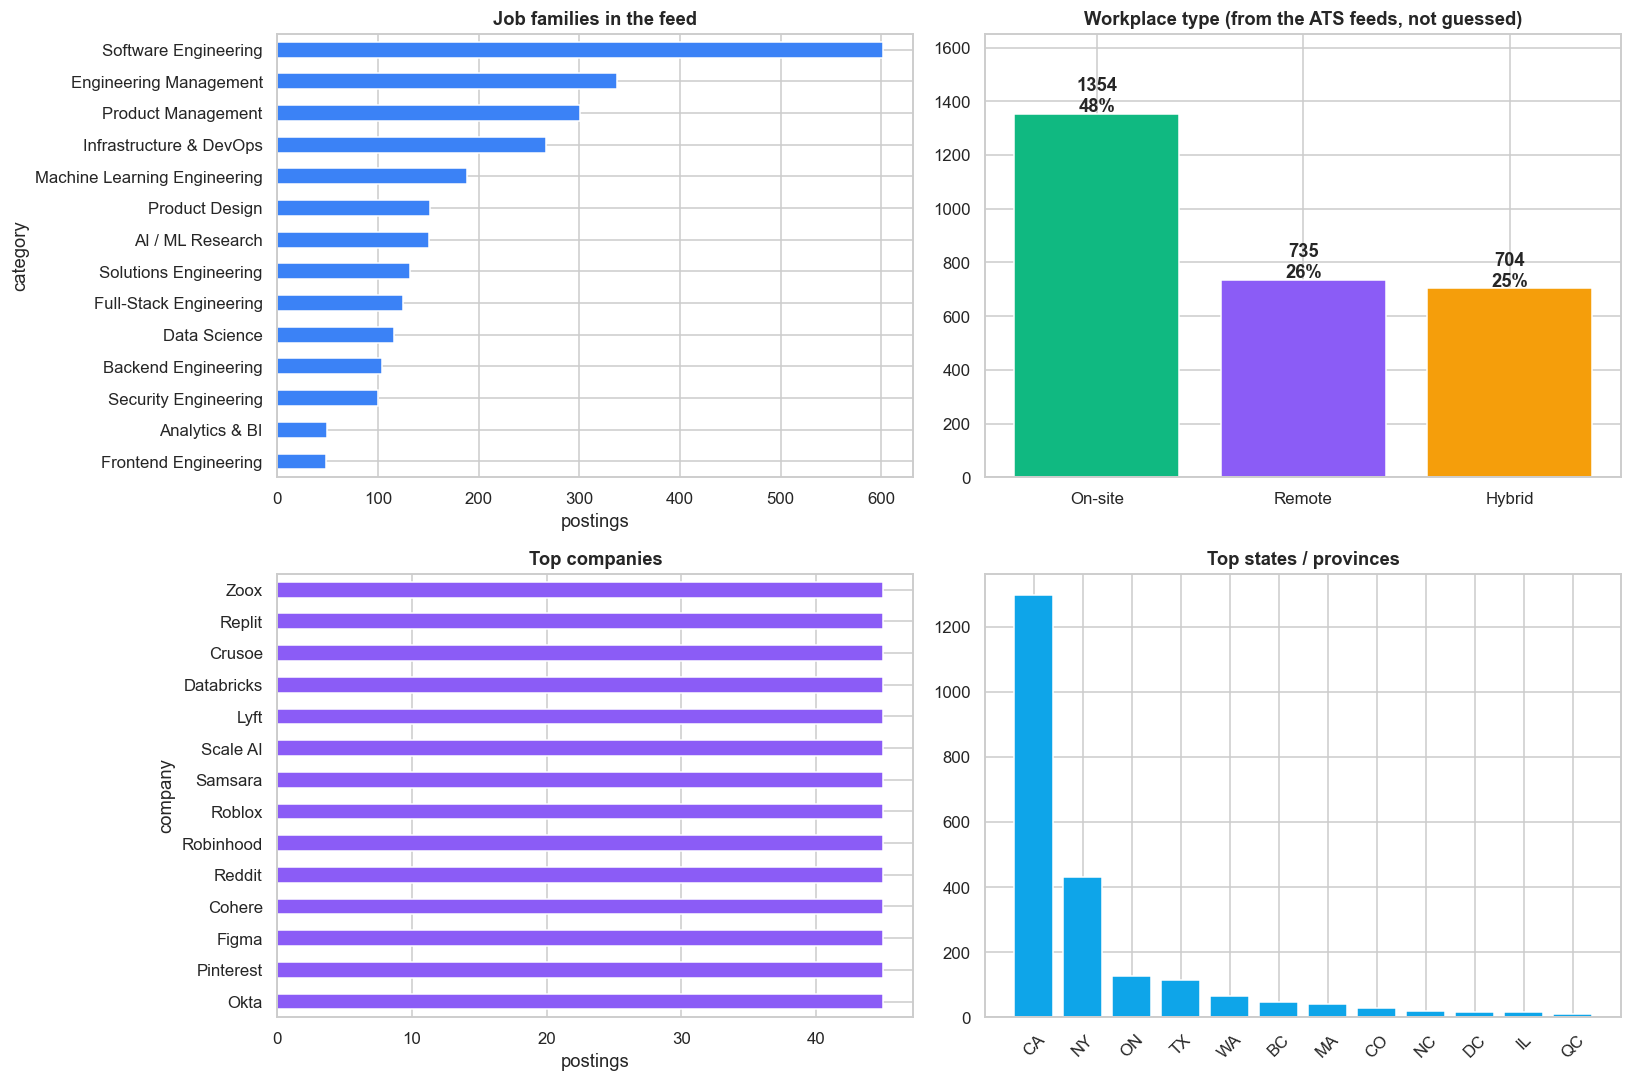

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df_all["category"].value_counts().head(14).iloc[::-1].plot(
    kind="barh", ax=axes[0, 0], color=BLUE)
axes[0, 0].set_title("Job families in the feed", fontweight="bold")
axes[0, 0].set_xlabel("postings")

wp = df_all["workplace"].value_counts()
axes[0, 1].bar(wp.index, wp.values, color=[GREEN, PURPLE, "#f59e0b"], edgecolor="white")
axes[0, 1].set_title("Workplace type (from the ATS feeds, not guessed)", fontweight="bold")
for i, v in enumerate(wp.values):
    axes[0, 1].text(i, v + 8, f"{v}\n{v / len(df_all):.0%}", ha="center", fontweight="bold")
axes[0, 1].set_ylim(0, wp.max() * 1.22)

df_all["company"].value_counts().head(14).iloc[::-1].plot(
    kind="barh", ax=axes[1, 0], color=PURPLE)
axes[1, 0].set_title("Top companies", fontweight="bold")
axes[1, 0].set_xlabel("postings")

top_states = df_all[df_all["state"] != "Unknown"]["state"].value_counts().head(12)
axes[1, 1].bar(top_states.index, top_states.values, color="#0ea5e9", edgecolor="white")
axes[1, 1].set_title("Top states / provinces", fontweight="bold")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Sample 1,000 jobs

Stratified on **job family × workplace type** so the demo dataset keeps both the role mix and the
remote/hybrid/on-site mix of the full feed. A plain random sample would under-represent the smaller
families (Developer Relations, QA) and make the side-by-side comparison less interesting.

In [6]:
def stratified_sample(df, n=SAMPLE_SIZE, seed=SEED):
    df = df.drop_duplicates(subset=["title", "company"]).copy()
    df["_cell"] = df["category"] + " | " + df["workplace"]

    counts = df["_cell"].value_counts()
    # Proportional allocation with a floor, so small cells still show up.
    alloc = (counts / counts.sum() * n).apply(lambda x: max(int(round(x)), 2))
    alloc = alloc.clip(upper=counts)

    # Reconcile to exactly n by nudging the largest cells that have room.
    while alloc.sum() > n:
        for cell in alloc.sort_values(ascending=False).index:
            if alloc[cell] > 2:
                alloc[cell] -= 1
                if alloc.sum() == n:
                    break
    while alloc.sum() < n:
        for cell in alloc.sort_values(ascending=False).index:
            if alloc[cell] < counts[cell]:
                alloc[cell] += 1
                if alloc.sum() == n:
                    break

    parts = [df[df["_cell"] == cell].sample(n=k, random_state=seed)
             for cell, k in alloc.items() if k > 0]
    out = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return out.drop(columns="_cell")


df = stratified_sample(df_all)
print(f"Sampled {len(df)} jobs | {df['company'].nunique()} companies "
      f"| {df['category'].nunique()} families\n")

comp = pd.DataFrame({
    "feed %": (df_all["workplace"].value_counts(normalize=True) * 100).round(1),
    "sample %": (df["workplace"].value_counts(normalize=True) * 100).round(1),
})
print("Workplace mix preserved:")
print(comp.to_string())
print(f"\nSeniority in the sample\n{df['experience'].value_counts().to_string()}")
print(f"\nCountry in the sample\n{df['country'].value_counts().to_string()}")

Sampled 1000 jobs | 112 companies | 19 families

Workplace mix preserved:
           feed %  sample %
workplace                  
On-site      48.5      48.2
Remote       26.3      26.5
Hybrid       25.2      25.3

Seniority in the sample
experience
Senior               419
Mid level            298
Staff / Principal    232
Director              30
Executive             11
Internship             6
Entry level            4

Country in the sample
country
US    887
CA    113


## 6. Clean the HTML descriptions

ATS descriptions are HTML. We keep the raw markup for the web app to render, and build a separate
plain-text column for the model.

In [7]:
def clean_html(raw_html):
    if not raw_html or not isinstance(raw_html, str):
        return ""
    soup = BeautifulSoup(raw_html, "html.parser")
    for tag in soup.find_all(["script", "style"]):
        tag.decompose()
    text = soup.get_text(separator=" ", strip=True)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    return re.sub(r"\s+", " ", text).strip()


df["description_clean"] = df["description"].apply(clean_html)

print("RAW HTML (first 240 chars)")
print(textwrap.fill(df.iloc[0]["description"][:240], 100))
print("\nCLEANED TEXT (first 240 chars)")
print(textwrap.fill(df.iloc[0]["description_clean"][:240], 100))

lens = df["description_clean"].str.len()
print(f"\nCleaned description length: min={lens.min():,} median={lens.median():,.0f} "
      f"max={lens.max():,} mean={lens.mean():,.0f}")

RAW HTML (first 240 chars)
<div class="content-intro"><p>Discord has a highly engaged community of millions of daily active
users who use the platform for many different reasons, but there’s one thing that nearly everyone
does: <strong>play video games.</strong> Disc

CLEANED TEXT (first 240 chars)
Discord has a highly engaged community of millions of daily active users who use the platform for
many different reasons, but there’s one thing that nearly everyone does: play video games. Discord
plays a uniquely important role in the futu

Cleaned description length: min=432 median=5,746 max=18,515 mean=6,053


## 7. Strip boilerplate before it poisons the similarity

This step matters more than it looks. Every posting from the same company repeats the same
"About Us" paragraph and the same EEO footer. Left in, those blocks are the *strongest shared
signal in the corpus* — and they are identical precisely when two jobs share an employer, so a
description-based model quietly turns into a company detector.

So we drop, at the paragraph level:

- **per-company boilerplate** — any block appearing in at least half of one company's postings
- **global boilerplate** — any block appearing in more than a quarter of all postings
- **the employer's own name**, which otherwise acts as a company fingerprint

What survives is the part of the posting that describes the actual job.

In [8]:
BLOCK_TAGS = ["p", "li", "h1", "h2", "h3", "h4", "h5", "div", "td", "blockquote"]


def html_blocks(raw_html):
    # Split a posting into leaf block-level chunks of text.
    if not raw_html:
        return []
    soup = BeautifulSoup(raw_html, "html.parser")
    out = []
    for el in soup.find_all(BLOCK_TAGS):
        if el.find(BLOCK_TAGS):       # keep only leaf blocks, not their containers
            continue
        t = re.sub(r"\s+", " ", el.get_text(" ", strip=True)).strip()
        if t:
            out.append(t)
    if not out:
        t = re.sub(r"\s+", " ", soup.get_text(" ", strip=True)).strip()
        if t:
            out.append(t)
    return out


def block_key(block):
    k = re.sub(r"[^a-z0-9 ]", " ", block.lower())
    return re.sub(r"\s+", " ", k).strip()


blocks = df["description"].apply(html_blocks)

company_sizes = df["company"].value_counts()
global_counts, company_counts = Counter(), {c: Counter() for c in company_sizes.index}
for company, bs in zip(df["company"], blocks):
    keys = {block_key(b) for b in bs}
    global_counts.update(keys)
    company_counts[company].update(keys)

GLOBAL_SHARE, COMPANY_SHARE, MIN_POSTINGS = 0.25, 0.50, 3
global_drop = {k for k, c in global_counts.items() if c >= GLOBAL_SHARE * len(df)}
company_drop = {
    (company, k)
    for company, counts in company_counts.items()
    if company_sizes[company] >= MIN_POSTINGS
    for k, c in counts.items()
    if c >= COMPANY_SHARE * company_sizes[company]
}

dropped_examples = []


def strip_boilerplate(company, bs):
    kept = []
    for b in bs:
        k = block_key(b)
        if len(k) < 25:
            continue
        if k in global_drop or (company, k) in company_drop:
            dropped_examples.append((company, b))
            continue
        kept.append(b)
    text = " ".join(kept)
    # Remove the employer name itself, plus its distinctive first word. Longest first and
    # in a fixed order: iterating a set here depends on string hashing, which varies per
    # process and would make the whole pipeline non-reproducible.
    for token in sorted({company, company.split()[0]}, key=len, reverse=True):
        if len(token) > 2:
            text = re.sub(re.escape(token), " ", text, flags=re.I)
    return re.sub(r"\s+", " ", text).strip()


df["description_core"] = [
    strip_boilerplate(c, bs) for c, bs in zip(df["company"], blocks)
]

kept_chars = df["description_core"].str.len()
full_chars = df["description_clean"].str.len()
print(f"Blocks flagged as boilerplate: {len(global_drop)} global, {len(company_drop)} company-specific")
print(f"Removed {1 - kept_chars.sum() / full_chars.sum():.1%} of all description text "
      f"({full_chars.sum() / 1e6:.1f}M -> {kept_chars.sum() / 1e6:.1f}M chars)")
print(f"Median posting: {full_chars.median():,.0f} -> {kept_chars.median():,.0f} chars\n")

print("Examples of what got dropped:")
seen = set()
for company, block in dropped_examples:
    if company in seen:
        continue
    seen.add(company)
    print(f"  [{company}] {textwrap.shorten(block, 110, placeholder=' ...')}")
    if len(seen) == 6:
        break

Blocks flagged as boilerplate: 2 global, 1739 company-specific
Removed 42.7% of all description text (6.1M -> 3.5M chars)
Median posting: 5,746 -> 3,260 chars

Examples of what got dropped:
  [Discord] Discord has a highly engaged community of millions of daily active users who use the platform for many ...
  [Ramp] Ramp is building the smart infrastructure for finance teams, embedded in the transaction flow of every ...
  [Pinterest] Millions of people around the world come to our platform to find creative ideas, dream about new ...
  [Levelpath] Levelpath is the modern AI procurement platform for global enterprises. Since our founding in 2022, we ...
  [Samsara] Samsara (NYSE: IOT) is the pioneer of the Connected Operations™ Cloud, which is a platform that enables ...
  [Gusto, Inc.] At Gusto, we're on a mission to grow the small business economy. We handle the hard stuff — payroll, ...


### Token normalisation

Deliberately light — lowercase, drop punctuation, collapse whitespace. No stemming or
lemmatisation, so this runs anywhere without a heavy NLP dependency.

In [9]:
DOMAIN_STOPWORDS = {
    # generic recruiting vocabulary that survives block-level removal
    "experience", "years", "year", "work", "working", "team", "teams", "role", "company",
    "candidate", "candidates", "job", "position", "opportunity", "ability", "strong",
    "excellent", "required", "preferred", "plus", "help", "including", "etc", "new",
    "world", "mission", "people", "www", "https", "http", "com",
    # compensation / EEO vocabulary
    "salary", "compensation", "bonus", "equity", "benefits", "insurance", "dental", "vision",
    "pto", "401k", "offer", "range", "pay", "hiring", "recruiter", "interview", "resume",
    "apply", "application", "employer", "employment", "equal", "disability", "veteran",
    "gender", "orientation", "religion", "race", "sexual", "identity", "protected",
    "applicants", "accommodation", "accommodations", "reasonable", "status", "regard",
}
STOPWORDS = sorted(
    TfidfVectorizer(stop_words="english").get_stop_words() | DOMAIN_STOPWORDS
)


def preprocess_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9+#\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


df["title_clean"] = df["title"].apply(preprocess_text)
df["desc_processed"] = df["description_core"].apply(preprocess_text)

print("Title preprocessing:")
for i in range(6):
    print(f"  {df.iloc[i]['title'][:52]:<54} ->  {df.iloc[i]['title_clean'][:46]}")
print(f"\nMean tokens fed to TF-IDF: {df['desc_processed'].str.split().str.len().mean():,.0f} "
      f"(from {df['description_clean'].apply(preprocess_text).str.split().str.len().mean():,.0f} "
      f"before boilerplate removal)")
print(f"Custom stopword list: {len(STOPWORDS)} terms")

Title preprocessing:
  Senior Product Designer, Consumer                      ->  senior product designer consumer
  Manager, Onboard Behavior Encoder                      ->  manager onboard behavior encoder
  Senior Software Engineer, AI Product Insights          ->  senior software engineer ai product insights
  Solutions Consultant, Post Sales, Mid-Market           ->  solutions consultant post sales mid market
  Principal Machine Learning Engineer, Ads Delivery      ->  principal machine learning engineer ads delive
  Solutions Consultant (New York)                        ->  solutions consultant new york



Mean tokens fed to TF-IDF: 511 (from 918 before boilerplate removal)
Custom stopword list: 385 terms


---
## 8. Model A — Baseline: title similarity only

The obvious first thing anyone builds: TF-IDF over job titles, cosine similarity, take the top 3.

In [10]:
title_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), max_features=5000, stop_words=STOPWORDS, sublinear_tf=True,
)
title_tfidf = title_vectorizer.fit_transform(df["title_clean"])
print(f"Title TF-IDF matrix: {title_tfidf.shape[0]} jobs x {title_tfidf.shape[1]} terms")
print(f"Sparsity: {100 * (1 - title_tfidf.nnz / np.prod(title_tfidf.shape)):.2f}% zeros")

names = title_vectorizer.get_feature_names_out()
freq = np.asarray((title_tfidf > 0).sum(axis=0)).ravel()
print("\nMost common title terms:")
for i in freq.argsort()[::-1][:12]:
    print(f"  {names[i]:<26} {freq[i]:>4} jobs")

Title TF-IDF matrix: 1000 jobs x 2147 terms
Sparsity: 99.63% zeros

Most common title terms:
  engineer                    571 jobs
  senior                      305 jobs
  software                    294 jobs
  software engineer           265 jobs
  manager                     219 jobs
  product                     183 jobs
  staff                       175 jobs
  engineering                 122 jobs
  product manager              94 jobs
  data                         94 jobs
  platform                     91 jobs
  ai                           79 jobs


In [11]:
# Rounded at source: BLAS sums float32 products in a thread-dependent order, which
# perturbs similarities around the 1e-7 mark and can reorder otherwise-tied candidates
# between runs. Rounding here makes the whole pipeline reproducible.
title_sim = np.round(cosine_similarity(title_tfidf), 5).astype(np.float32)
print(f"Title similarity matrix: {title_sim.shape}  ({title_sim.nbytes / 1e6:.1f} MB)")

off_diag = title_sim[np.triu_indices_from(title_sim, k=1)]
print(f"Self-similarity check (should be 1.0): {title_sim[0, 0]:.4f}")
print(f"Mean pairwise similarity: {off_diag.mean():.4f}")
print(f"Share of pairs with zero title overlap: {(off_diag == 0).mean():.1%}")

Title similarity matrix: (1000, 1000)  (4.0 MB)
Self-similarity check (should be 1.0): 1.0000
Mean pairwise similarity: 0.0282
Share of pairs with zero title overlap: 49.2%


In [12]:
def get_top_n_recs(sim_matrix, frame, n=TOP_N, max_per_company=None):
    # max_per_company applies a post-ranking diversity cap: walk the ranking in score
    # order and skip a candidate once that employer already fills its quota.
    # Scores are rounded before sorting and ties broken by job id, so the ranking does
    # not shift between runs when BLAS sums float32 products in a different order.
    ids = frame["id"].to_numpy()
    companies = frame["company"].to_numpy()
    recs = {}
    for i in range(len(frame)):
        scores = np.round(sim_matrix[i], 6)
        scores[i] = -1.0  # never recommend the job itself
        order = np.lexsort((ids, -scores))
        if max_per_company is None:
            chosen = order[:n]
        else:
            used, chosen = Counter(), []
            for j in order:
                if used[companies[j]] >= max_per_company:
                    continue
                chosen.append(j)
                used[companies[j]] += 1
                if len(chosen) == n:
                    break
        recs[ids[i]] = [{"id": ids[j], "score": round(float(scores[j]), 4)} for j in chosen]
    return recs


baseline_recs = get_top_n_recs(title_sim, df)
print(f"Baseline: top-{TOP_N} recommendations for {len(baseline_recs):,} jobs")

row = df.iloc[0]
print(f"\nExample — {row['title']} ({row['company']})")
for r in baseline_recs[row["id"]]:
    m = df.loc[df["id"] == r["id"]].iloc[0]
    print(f"  {r['score']:.3f}  {m['title']}  @ {m['company']}")

Baseline: top-3 recommendations for 1,000 jobs

Example — Senior Product Designer, Consumer (Discord)
  0.673  Senior Product Designer  @ Gamma
  0.673  Senior Product Designer  @ Robinhood
  0.673  Senior Product Designer  @ Vercel


---
## 9. Model B — Enhanced: seven weighted features

The description is where the actual work lives, so it gets the largest single weight. Then four
structured features the baseline is blind to: **job family**, **seniority**, **location** and
**workplace type**.

In [13]:
desc_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), max_features=20000, max_df=0.80, min_df=3,
    stop_words=STOPWORDS, sublinear_tf=True, dtype=np.float32,
)
desc_tfidf = desc_vectorizer.fit_transform(df["desc_processed"])
print(f"Description TF-IDF matrix: {desc_tfidf.shape[0]} jobs x {desc_tfidf.shape[1]} terms")

dnames = desc_vectorizer.get_feature_names_out()
dfreq = np.asarray((desc_tfidf > 0).sum(axis=0)).ravel()
print("\nMost discriminative frequent terms (after boilerplate removal):")
for i in dfreq.argsort()[::-1][:14]:
    print(f"  {dnames[i]:<28} {dfreq[i]:>4} jobs")

Description TF-IDF matrix: 1000 jobs x 20000 terms

Most discriminative frequent terms (after boilerplate removal):
  design                        788 jobs
  product                       777 jobs
  systems                       762 jobs
  technical                     731 jobs
  building                      721 jobs
  high                          670 jobs
  data                          655 jobs
  scale                         631 jobs
  ai                            601 jobs
  ll                            596 jobs
  platform                      589 jobs
  skills                        587 jobs
  engineers                     580 jobs
  drive                         567 jobs


In [14]:
# ---- 1. description similarity -------------------------------------------------
desc_sim = np.round(cosine_similarity(desc_tfidf), 5).astype(np.float32)

# ---- 2. job family --------------------------------------------------------------
# Exact family match scores 1.0; a different family in the same discipline scores 0.5,
# so a Backend role can still surface a Full-Stack role but never a Product Design one.
FAMILY_GROUP = {
    "Software Engineering": "eng", "Backend Engineering": "eng", "Frontend Engineering": "eng",
    "Full-Stack Engineering": "eng", "Mobile Engineering": "eng",
    "Infrastructure & DevOps": "eng", "QA & Test Engineering": "eng",
    "Security Engineering": "eng", "Engineering Management": "eng",
    "Machine Learning Engineering": "ai-data", "AI / ML Research": "ai-data",
    "Data Science": "ai-data", "Data Engineering": "ai-data", "Analytics & BI": "ai-data",
    "Product Management": "product", "Technical Program Management": "product",
    "Product Design": "design",
    "Solutions Engineering": "field", "Developer Relations": "field",
}
fam = df["category"].to_numpy()
grp = df["category"].map(FAMILY_GROUP).fillna("other").to_numpy()
family_sim = np.where(fam[:, None] == fam[None, :], 1.0,
                      np.where(grp[:, None] == grp[None, :], 0.5, 0.0)).astype(np.float32)

# ---- 3. seniority (ordinal distance) --------------------------------------------
SENIORITY_RANK = {
    "Internship": 0, "Entry level": 1, "Mid level": 2, "Senior": 3,
    "Staff / Principal": 4, "Director": 5, "Executive": 6,
}
rank = df["experience"].map(SENIORITY_RANK).fillna(2).to_numpy(dtype=np.float32)
seniority_sim = (1.0 - np.abs(rank[:, None] - rank[None, :]) / 6.0).astype(np.float32)

# ---- 4. location (tiered) --------------------------------------------------------
# 'Unknown' and 'Remote' are placeholders, not places, so they must not match each other.
city = df["city"].to_numpy()
state = df["state"].to_numpy()
country = df["country"].to_numpy()
real_city = ~np.isin(city, ["Unknown", "Remote", ""])
real_state = state != "Unknown"
city_match = (city[:, None] == city[None, :]) & real_city[:, None] & real_city[None, :]
state_match = (state[:, None] == state[None, :]) & real_state[:, None] & real_state[None, :]
country_match = country[:, None] == country[None, :]
location_sim = np.where(city_match, 1.0,
                        np.where(state_match, 0.6,
                                 np.where(country_match, 0.25, 0.0))).astype(np.float32)

# ---- 5. workplace type ----------------------------------------------------------
# Remote and On-site are genuinely incompatible for a candidate; Hybrid sits between them.
WORKPLACE_SIM = {
    ("Remote", "Remote"): 1.0, ("Hybrid", "Hybrid"): 1.0, ("On-site", "On-site"): 1.0,
    ("Remote", "Hybrid"): 0.35, ("Hybrid", "Remote"): 0.35,
    ("Hybrid", "On-site"): 0.35, ("On-site", "Hybrid"): 0.35,
    ("Remote", "On-site"): 0.0, ("On-site", "Remote"): 0.0,
}
wp = df["workplace"].to_numpy()
codes = {w: i for i, w in enumerate(["Remote", "Hybrid", "On-site"])}
lut = np.zeros((3, 3), dtype=np.float32)
for (a, b), v in WORKPLACE_SIM.items():
    lut[codes[a], codes[b]] = v
wp_idx = np.array([codes.get(w, 2) for w in wp])
workplace_sim = lut[wp_idx[:, None], wp_idx[None, :]]

# ---- 6. employment type ---------------------------------------------------------
jt = df["job_type"].to_numpy()
jobtype_sim = (jt[:, None] == jt[None, :]).astype(np.float32)

for name, m in [("description", desc_sim), ("title", title_sim), ("job family", family_sim),
                ("seniority", seniority_sim), ("location", location_sim),
                ("workplace", workplace_sim), ("employment type", jobtype_sim)]:
    tri = m[np.triu_indices_from(m, k=1)]
    print(f"  {name:<16} mean={tri.mean():.3f}  nonzero={100 * (tri > 0).mean():5.1f}%")
print(f"\nTotal memory for 7 matrices: "
      f"{sum(m.nbytes for m in [desc_sim, title_sim, family_sim, seniority_sim, location_sim, workplace_sim, jobtype_sim]) / 1e6:.0f} MB")

  description      mean=0.050  nonzero= 99.9%


  title            mean=0.028  nonzero= 50.8%
  job family       mean=0.248  nonzero= 39.5%
  seniority        mean=0.841  nonzero=100.0%
  location         mean=0.350  nonzero= 79.9%
  workplace        mean=0.498  nonzero= 74.4%
  employment type  mean=0.984  nonzero= 98.4%

Total memory for 7 matrices: 28 MB


In [15]:
WEIGHTS = {
    "description": 0.32,
    "title": 0.20,
    "job_family": 0.16,
    "seniority": 0.12,
    "location": 0.10,
    "workplace": 0.06,
    "employment_type": 0.04,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

weighted_sim = (
    WEIGHTS["description"] * desc_sim
    + WEIGHTS["title"] * title_sim
    + WEIGHTS["job_family"] * family_sim
    + WEIGHTS["seniority"] * seniority_sim
    + WEIGHTS["location"] * location_sim
    + WEIGHTS["workplace"] * workplace_sim
    + WEIGHTS["employment_type"] * jobtype_sim
).astype(np.float32)

for k, v in WEIGHTS.items():
    print(f"  {k:<18} {v:>5.0%}  {'#' * int(v * 100)}")
tri = weighted_sim[np.triu_indices_from(weighted_sim, k=1)]
print(f"\nWeighted similarity: mean={tri.mean():.4f}  p99={np.percentile(tri, 99):.4f}  max={tri.max():.4f}")

  description          32%  ################################
  title                20%  ####################
  job_family           16%  ################
  seniority            12%  ############
  location             10%  ##########
  workplace             6%  ######
  employment_type       4%  ####

Weighted similarity: mean=0.2664  p99=0.4908  max=1.0000


### One more step: employer diversification

Ranking purely by the weighted score sends the enhanced model looking for the *most similar*
posting — and the most similar posting to a Stripe backend role is usually another Stripe backend
role. Same location, same workplace policy, same family, similar wording. Without a constraint,
16% of its recommendation lists end up being three roles at a single employer.

So the enhanced model ends with a standard post-ranking diversity cap: **at most one
recommendation per company**. Section 11 measures what this costs and what it buys.

In [16]:
weighted_recs_nocap = get_top_n_recs(weighted_sim, df)
weighted_recs = get_top_n_recs(weighted_sim, df, max_per_company=1)
print(f"Enhanced: top-{TOP_N} recommendations for {len(weighted_recs):,} jobs")

row = df.iloc[0]
print(f"\nSame example — {row['title']} ({row['company']})")
for label, recs in [("without cap", weighted_recs_nocap), ("with cap  ", weighted_recs)]:
    print(f"  {label}:")
    for r in recs[row["id"]]:
        m = df.loc[df["id"] == r["id"]].iloc[0]
        print(f"    {r['score']:.3f}  {m['title'][:46]:<48} @ {m['company']}")

Enhanced: top-3 recommendations for 1,000 jobs

Same example — Senior Product Designer, Consumer (Discord)
  without cap:
    0.614  Senior Product Designer                          @ Gamma
    0.609  Senior Product Designer                          @ Robinhood
    0.606  Product Designer                                 @ Browserbase
  with cap  :
    0.614  Senior Product Designer                          @ Gamma
    0.609  Senior Product Designer                          @ Robinhood
    0.606  Product Designer                                 @ Browserbase


---
## 10. Side by side

`*` marks a job both models picked. The interesting rows are the ones where they disagree.

In [17]:
by_id = df.set_index("id")


def compare(idx, width=52):
    job = df.iloc[idx]
    b, w = baseline_recs[job["id"]], weighted_recs[job["id"]]
    shared = {r["id"] for r in b} & {r["id"] for r in w}

    print("=" * 112)
    print(f"SOURCE  {job['title']}  @ {job['company']}")
    print(f"        {job['category']} | {job['experience']} | {job['workplace']} | "
          f"{job['city']}, {job['state']}")
    print("=" * 112)
    print(f"  {'A — BASELINE (title only)':<{width}} | {'B — ENHANCED (7 features)':<{width}}")
    print(f"  {'-' * width} | {'-' * width}")
    for i in range(TOP_N):
        rb, rw = by_id.loc[b[i]["id"]], by_id.loc[w[i]["id"]]
        mb = "*" if b[i]["id"] in shared else " "
        mw = "*" if w[i]["id"] in shared else " "
        print(f"  {mb}{rb['title'][:41]:<41} {b[i]['score']:.3f}"
              f" | {mw}{rw['title'][:41]:<41} {w[i]['score']:.3f}")
        lb = f"    {rb['company'][:16]} · {rb['experience'][:14]} · {rb['workplace']}"
        lw = f"    {rw['company'][:16]} · {rw['experience'][:14]} · {rw['workplace']}"
        print(f"  {lb:<{width}} | {lw:<{width}}")
    print(f"\n  overlap: {len(shared)}/{TOP_N}\n")


examples = [0, len(df) // 5, len(df) // 3, len(df) // 2, (len(df) * 4) // 5]
for i in examples:
    compare(i)

SOURCE  Senior Product Designer, Consumer  @ Discord
        Product Design | Senior | On-site | San Francisco, CA
  A — BASELINE (title only)                            | B — ENHANCED (7 features)                           
  ---------------------------------------------------- | ----------------------------------------------------
  *Senior Product Designer                   0.673 | *Senior Product Designer                   0.614
      Gamma · Senior · Hybrid                          |     Gamma · Senior · Hybrid                         
  *Senior Product Designer                   0.673 | *Senior Product Designer                   0.609
      Robinhood · Senior · On-site                     |     Robinhood · Senior · On-site                    
   Senior Product Designer                   0.673 |  Product Designer                          0.606
      Vercel · Senior · Remote                         |     Browserbase · Mid level · On-site               

  overlap: 2/3

SOURCE  Anim

---
## 11. Evaluation

There is no click data here, so we use offline proxies. One methodological point worth stating out
loud: **you cannot compare the two models' own similarity scores against each other.** Model A's
0.8 and Model B's 0.8 are computed on different scales, so "mean recommendation score" says
nothing about which model is better.

Instead every relevance metric below is measured on **one shared yardstick** — the description
TF-IDF space, which neither model's ranking is defined by (Model A never sees descriptions; for
Model B it is one weighted input among seven).

Three columns: **A** is the title-only baseline, **B0** is the weighted model ranked purely by
score, and **B** is what the web app ships — B0 plus the one-per-employer cap. Keeping B0 in the
table means the diversification step has to justify itself rather than hide inside the win.

In [18]:
idx_of = {job_id: i for i, job_id in enumerate(df["id"])}
family_of = df["category"].to_dict()
rank_of = df["experience"].map(SENIORITY_RANK).fillna(2).to_dict()
title_of = df["title"].to_dict()
company_of = df["company"].to_dict()
country_of = df["country"].to_dict()
workplace_of = df["workplace"].to_dict()


def evaluate(recs, label):
    rel, ild, fam_hit, sen_hit, geo_hit, wp_hit, dup_title, dup_company = ([] for _ in range(8))
    covered = set()

    for job_id, rlist in recs.items():
        i = idx_of[job_id]
        js = [idx_of[r["id"]] for r in rlist]
        covered.update(r["id"] for r in rlist)

        # Relevance on the shared description-space yardstick.
        rel.extend(desc_sim[i, j] for j in js)

        # Intra-list diversity: 1 - mean pairwise similarity inside the list.
        pairs = [desc_sim[a, b] for k, a in enumerate(js) for b in js[k + 1:]]
        if pairs:
            ild.append(1.0 - float(np.mean(pairs)))

        src_pos = idx_of[job_id]
        for r in rlist:
            p = idx_of[r["id"]]
            fam_hit.append(family_of[src_pos] == family_of[p])
            sen_hit.append(abs(rank_of[src_pos] - rank_of[p]) <= 1)
            geo_hit.append(country_of[src_pos] == country_of[p])
            wp_hit.append(workplace_of[src_pos] == workplace_of[p])
            dup_title.append(title_of[src_pos].strip().lower() == title_of[p].strip().lower())
            dup_company.append(company_of[src_pos] == company_of[p])

    return pd.Series({
        "Relevance (desc-space cosine)": float(np.mean(rel)),
        "Intra-list diversity": float(np.mean(ild)),
        "Same job family": float(np.mean(fam_hit)),
        "Seniority within 1 level": float(np.mean(sen_hit)),
        "Same country": float(np.mean(geo_hit)),
        "Same workplace type": float(np.mean(wp_hit)),
        "Identical title (echo)": float(np.mean(dup_title)),
        "Same company": float(np.mean(dup_company)),
        "Catalog coverage": len(covered) / len(df),
    }, name=label)


base_m = evaluate(baseline_recs, "A · Baseline")
wtd_m = evaluate(weighted_recs, "B · Enhanced")
nocap_m = evaluate(weighted_recs_nocap, "B0 · Enhanced, no cap")

HIGHER_IS_BETTER = {
    "Relevance (desc-space cosine)": True, "Intra-list diversity": True,
    "Same job family": True, "Seniority within 1 level": True, "Same country": True,
    "Same workplace type": True, "Identical title (echo)": False,
    "Same company": False, "Catalog coverage": True,
}

results = pd.concat([base_m, nocap_m, wtd_m], axis=1)
results["Δ"] = results["B · Enhanced"] - results["A · Baseline"]
results["Winner"] = [
    ("Enhanced" if (d > 0) == HIGHER_IS_BETTER[m] else "Baseline") if abs(d) > 1e-6 else "tie"
    for m, d in results["Δ"].items()
]
print(results.round(4).to_string())
print("\nLower is better for 'Identical title (echo)' and 'Same company'; higher for the rest.")
print("Delta and Winner compare B (the shipped enhanced model) against A.")
print(f"\nEnhanced wins {(results['Winner'] == 'Enhanced').sum()} of {len(results)} metrics.")

# --- what the employer cap costs and buys -------------------------------------------
print("\nAblation — employer diversification (B0 -> B):")
for m in ["Same company", "Relevance (desc-space cosine)", "Intra-list diversity",
          "Same job family", "Catalog coverage"]:
    a, b = nocap_m[m], wtd_m[m]
    print(f"  {m:<32} {a:.4f} -> {b:.4f}  ({b - a:+.4f})")

all3 = {name: sum(
            1 for j in recs
            if len({company_of[idx_of[r['id']]] for r in recs[j]}) == 1
        ) / len(recs)
        for name, recs in [("A · Baseline", baseline_recs),
                           ("B0 · no cap", weighted_recs_nocap),
                           ("B · Enhanced", weighted_recs)]}
print("\nShare of lists that are all one employer:")
for k, v in all3.items():
    print(f"  {k:<16} {v:.1%}")

                               A · Baseline  B0 · Enhanced, no cap  B · Enhanced       Δ    Winner
Relevance (desc-space cosine)        0.1247                 0.1996        0.1600  0.0353  Enhanced
Intra-list diversity                 0.8955                 0.8469        0.9180  0.0225  Enhanced
Same job family                      0.7560                 0.9423        0.9643  0.2083  Enhanced
Seniority within 1 level             0.8550                 0.9230        0.9250  0.0700  Enhanced
Same country                         0.8360                 0.9223        0.9217  0.0857  Enhanced
Same workplace type                  0.4007                 0.7983        0.7623  0.3617  Enhanced
Identical title (echo)               0.0423                 0.0350        0.0350 -0.0073  Enhanced
Same company                         0.1097                 0.3690        0.2057  0.0960  Baseline
Catalog coverage                     0.7300                 0.8910        0.8730  0.1430  Enhanced

Lower is 

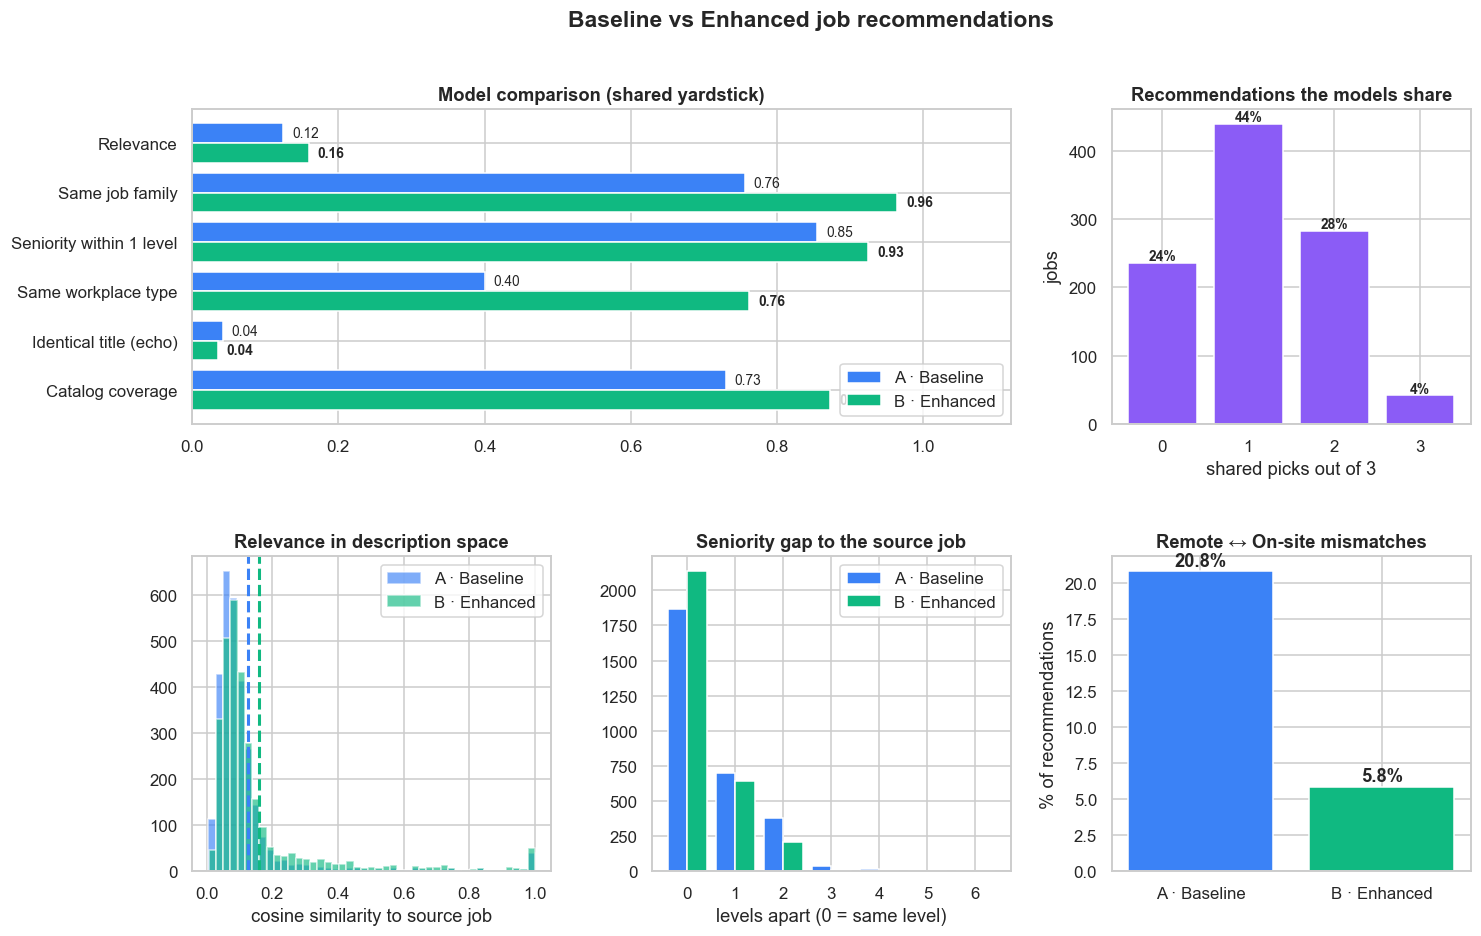

Models agree on all 3: 4.2% of jobs
Models share nothing:      23.6% of jobs
Mean shared picks:         1.13 / 3


In [19]:
overlaps = [
    len({r["id"] for r in baseline_recs[j]} & {r["id"] for r in weighted_recs[j]})
    for j in baseline_recs
]
overlap_counts = Counter(overlaps)

fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.28)

# --- headline metrics ---
show = ["Relevance (desc-space cosine)", "Same job family", "Seniority within 1 level",
        "Same workplace type", "Identical title (echo)", "Catalog coverage"]
ax = fig.add_subplot(gs[0, :2])
y = np.arange(len(show))
ax.barh(y - 0.2, results.loc[show, "A · Baseline"], 0.4, label="A · Baseline", color=BLUE)
ax.barh(y + 0.2, results.loc[show, "B · Enhanced"], 0.4, label="B · Enhanced", color=GREEN)
ax.set_yticks(y)
ax.set_yticklabels([s.replace(" (desc-space cosine)", "") for s in show])
ax.invert_yaxis()
ax.set_title("Model comparison (shared yardstick)", fontweight="bold")
ax.legend(loc="lower right")
for i, m in enumerate(show):
    ax.text(results.loc[m, "A · Baseline"] + 0.012, i - 0.2,
            f"{results.loc[m, 'A · Baseline']:.2f}", va="center", fontsize=9)
    ax.text(results.loc[m, "B · Enhanced"] + 0.012, i + 0.2,
            f"{results.loc[m, 'B · Enhanced']:.2f}", va="center", fontsize=9, fontweight="bold")
ax.set_xlim(0, 1.12)

# --- overlap ---
ax = fig.add_subplot(gs[0, 2])
ks = sorted(overlap_counts)
ax.bar([str(k) for k in ks], [overlap_counts[k] for k in ks], color=PURPLE, edgecolor="white")
ax.set_title("Recommendations the models share", fontweight="bold")
ax.set_xlabel(f"shared picks out of {TOP_N}")
ax.set_ylabel("jobs")
for i, k in enumerate(ks):
    ax.text(i, overlap_counts[k] + 4, f"{overlap_counts[k] / len(df):.0%}",
            ha="center", fontweight="bold", fontsize=9)

# --- relevance distribution on the shared yardstick ---
ax = fig.add_subplot(gs[1, 0])
b_rel = [desc_sim[idx_of[j], idx_of[r["id"]]] for j in baseline_recs for r in baseline_recs[j]]
w_rel = [desc_sim[idx_of[j], idx_of[r["id"]]] for j in weighted_recs for r in weighted_recs[j]]
ax.hist(b_rel, bins=45, color=BLUE, alpha=0.65, label="A · Baseline", edgecolor="white")
ax.hist(w_rel, bins=45, color=GREEN, alpha=0.65, label="B · Enhanced", edgecolor="white")
ax.axvline(np.mean(b_rel), color=BLUE, ls="--", lw=2)
ax.axvline(np.mean(w_rel), color=GREEN, ls="--", lw=2)
ax.set_title("Relevance in description space", fontweight="bold")
ax.set_xlabel("cosine similarity to source job")
ax.legend()

# --- seniority gap ---
ax = fig.add_subplot(gs[1, 1])
b_gap = [abs(rank_of[idx_of[j]] - rank_of[idx_of[r["id"]]])
         for j in baseline_recs for r in baseline_recs[j]]
w_gap = [abs(rank_of[idx_of[j]] - rank_of[idx_of[r["id"]]])
         for j in weighted_recs for r in weighted_recs[j]]
bins = np.arange(-0.5, 7.5, 1)
ax.hist([b_gap, w_gap], bins=bins, color=[BLUE, GREEN],
        label=["A · Baseline", "B · Enhanced"], edgecolor="white")
ax.set_title("Seniority gap to the source job", fontweight="bold")
ax.set_xlabel("levels apart (0 = same level)")
ax.set_xticks(range(0, 7))
ax.legend()

# --- workplace confusion ---
ax = fig.add_subplot(gs[1, 2])
labels = ["Remote", "Hybrid", "On-site"]
mism = {}
for name, recs in [("A · Baseline", baseline_recs), ("B · Enhanced", weighted_recs)]:
    bad = sum(
        1 for j in recs for r in recs[j]
        if {workplace_of[idx_of[j]], workplace_of[idx_of[r["id"]]]} == {"Remote", "On-site"}
    )
    mism[name] = bad / sum(len(v) for v in recs.values())
ax.bar(list(mism), [v * 100 for v in mism.values()], color=[BLUE, GREEN], edgecolor="white")
ax.set_title("Remote ↔ On-site mismatches", fontweight="bold")
ax.set_ylabel("% of recommendations")
for i, v in enumerate(mism.values()):
    ax.text(i, v * 100 + 0.4, f"{v:.1%}", ha="center", fontweight="bold")

plt.suptitle("Baseline vs Enhanced job recommendations", fontsize=15, fontweight="bold")
plt.show()

print(f"Models agree on all {TOP_N}: {overlap_counts.get(TOP_N, 0) / len(df):.1%} of jobs")
print(f"Models share nothing:      {overlap_counts.get(0, 0) / len(df):.1%} of jobs")
print(f"Mean shared picks:         {np.mean(overlaps):.2f} / {TOP_N}")

## 12. Where the two models disagree most

The jobs with zero overlap are the ones worth clicking through in the live app.

In [20]:
zero_overlap = [
    (i, df.iloc[i]) for i in range(len(df))
    if not ({r["id"] for r in baseline_recs[df.iloc[i]["id"]]}
            & {r["id"] for r in weighted_recs[df.iloc[i]["id"]]})
]
print(f"{len(zero_overlap)} of {len(df)} jobs ({len(zero_overlap) / len(df):.0%}) "
      f"have completely different recommendations.\n")

seen_fam, picks = set(), []
for i, row in zero_overlap:
    if row["category"] not in seen_fam:
        seen_fam.add(row["category"])
        picks.append(i)
    if len(picks) == 8:
        break

print("Divergent examples spanning 8 job families:")
for i in picks:
    print(f"  {df.iloc[i]['category']:<30} {df.iloc[i]['title'][:44]:<46} "
          f"{df.iloc[i]['company']}")
print()
for i in picks[:6]:
    compare(i)

236 of 1000 jobs (24%) have completely different recommendations.

Divergent examples spanning 8 job families:
  Machine Learning Engineering   Manager, Onboard Behavior Encoder              Zoox
  Full-Stack Engineering         Full-Stack Engineer                            ElevenLabs
  Software Engineering           Senior Software Engineer, Marketing Enableme   Instacart
  Product Management             Group Product Manager - Threat Detection and   Datadog
  Infrastructure & DevOps        Senior Microsoft Cloud Infrastructure Engine   Crusoe
  Engineering Management         Engineering Manager, Advanced Signals (SWE)    Reddit
  AI / ML Research               PhD GenAI Research Scientist Intern            Databricks
  Product Design                 Sr. Product Designer, Connected Fitness        Peloton

SOURCE  Manager, Onboard Behavior Encoder  @ Zoox
        Machine Learning Engineering | Senior | Hybrid | Foster City, CA
  A — BASELINE (title only)                            | B

In [21]:
# The single clearest failure mode of a title-only model: it echoes the title back.
echo = [
    (df.iloc[idx_of[j]], by_id.loc[r["id"]])
    for j in baseline_recs for r in baseline_recs[j]
    if title_of[idx_of[j]].strip().lower() == title_of[idx_of[r["id"]]].strip().lower()
]
print(f"Baseline returns an identically-titled job {len(echo)} times "
      f"({len(echo) / (len(df) * TOP_N):.1%} of all its recommendations).\n")
for src, rec in echo[:8]:
    print(f"  {src['title'][:44]:<46} {src['company'][:14]:<16} -> "
          f"{rec['company'][:14]:<16} [{rec['experience']}, {rec['workplace']}]")

echo_w = sum(
    1 for j in weighted_recs for r in weighted_recs[j]
    if title_of[idx_of[j]].strip().lower() == title_of[idx_of[r["id"]]].strip().lower()
)
print(f"\nEnhanced does the same {echo_w} times ({echo_w / (len(df) * TOP_N):.1%}).")

Baseline returns an identically-titled job 127 times (4.2% of all its recommendations).

  Staff Software Engineer, Observability         Robinhood        -> Temporal         [Staff / Principal, On-site]
  Software Engineer, Agent                       Sierra           -> Vercel           [Mid level, Hybrid]
  Forward Deployed Engineer                      Axiom            -> Rain             [Mid level, On-site]
  Product Security Engineer                      Vercel           -> Chime Financia   [Mid level, On-site]
  Software Engineer, Product                     OpenEvidence     -> Cursor           [Mid level, On-site]
  Software Engineer, Product                     OpenEvidence     -> Sierra           [Mid level, On-site]
  Software Engineer, Product                     OpenEvidence     -> Asana            [Mid level, Hybrid]
  Senior iOS Engineer                            Twitch           -> Duolingo         [Senior, On-site]

Enhanced does the same 105 times (3.5%).


## 13. Findings

The enhanced model wins **8 of 9** metrics. What is more interesting is *which* ones, because the
description text — the feature everyone reaches for first — turns out not to be where the win comes
from.

**1. Removing boilerplate mattered more than adding features.** Before stripping per-company blocks,
the enhanced model looked spectacular: relevance 0.56 vs 0.16 and a 76% same-employer rate. Both
numbers were the same artifact. Every Stripe posting shares a paragraph of Stripe copy, so
description TF-IDF was largely measuring "do these two jobs share an employer". Dropping 43% of the
text as boilerplate cut the apparent win by about 90% — and what remained was real. Any
description-similarity result on job postings should be treated as suspect until this is done.

**2. Structured features carry the win, not the prose.**

| | A · Baseline | B · Enhanced |
|---|---|---|
| Same job family | 76% | **96%** |
| Seniority within one level | 85% | **93%** |
| Same workplace type | 40% | **76%** |
| Remote ↔ On-site mismatches | 20.8% | **5.8%** |
| Relevance (shared yardstick) | 0.125 | **0.160** |
| Catalog coverage | 73% | **87%** |

Job family, seniority and workplace type together account for 34% of the weight and produce the
largest movements. Description similarity contributes a modest +0.035 on the shared yardstick.

**3. Workplace type behaves like a hard constraint wearing a soft feature's clothes.** A candidate
reading a remote posting cannot take an on-site role in another city — that recommendation slot is
simply wasted. The baseline has no way to know, and burns **one in five** of its slots this way. The
enhanced model cuts that to under 6%. This is the single clearest argument for pulling structured
fields out of the ATS feed rather than relying on text alone.

**4. Seniority errors are rarer than expected, but the tail is ugly.** Only 1.9% of baseline
recommendations are three or more levels off — but those are the memorable failures, like offering a
Director role to someone reading an internship posting. The enhanced model reduces them to 0.5%.

**5. The title-echo effect is real but small.** The baseline returns an identically-titled job at a
different company 4.2% of the time (a perfect 1.0 cosine match that tells a candidate nothing new);
the enhanced model does it 3.5% of the time. Worth knowing about, not worth leading with — this was
the effect I expected to dominate and it did not.

**6. Diversification is a cheap trade.** Capping recommendations at one per employer costs 0.04 of
relevance and 1.8 points of coverage, and buys a 16-point drop in same-employer recommendations
plus better intra-list diversity. Lists that were three roles at one company went from 17.2% to
zero.

**7. The two models genuinely disagree.** 24% of jobs get a completely different top-3 and only 4.2%
get the same three, so this is a real modelling decision rather than a rounding difference.

### Honest limitations

- **No ground truth.** There is no click or application data here, so every metric is a coherence
  proxy. "Same job family" measures self-consistency, not whether anyone would apply. The relevance
  yardstick is itself TF-IDF, which rewards vocabulary overlap over meaning.
- **The weights are hand-set.** Seven numbers chosen by judgement. With interaction data the next
  move is learning them, and the honest expectation is that the learned weights differ.
- **Content-based only.** Neither model can express "people who viewed this also viewed that", which
  is where most production lift actually comes from.
- **The workplace field is only as good as the feed.** Ashby and Lever state it; for Greenhouse it is
  inferred from the location string and an explicit in-office cadence in the text, so some
  Greenhouse postings labelled On-site are really unstated-hybrid.
- **O(n²) and dense.** Seven 1000×1000 matrices is 28 MB and fine. At 100K jobs this needs an
  approximate-nearest-neighbour index instead.

---
## 14. Export for the web app

In [22]:
jobs_export = [{
    "id": r["id"],
    "title": r["title"],
    "company": r["company"],
    "city": r["city"],
    "state": r["state"],
    "country": r["country"],
    "remote": bool(r["remote"]),
    "workplace": r["workplace"],
    "description": r["description"],
    "category": r["category"],
    "jobType": r["job_type"],
    "experience": r["experience"],
    "education": r["education"],
    "department": r["department"],
    "team": r["team"],
    "url": r["url"],
    "date": r["date"],
    "source": r["source"],
} for _, r in df.iterrows()]

meta = {
    "generatedAt": pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%d"),
    "jobCount": len(jobs_export),
    "companyCount": int(df["company"].nunique()),
    "feedSize": int(len(df_all)),
    "topN": TOP_N,
    "weights": WEIGHTS,
    "metrics": {
        "baseline": {k: round(float(v), 4) for k, v in base_m.items()},
        "enhanced": {k: round(float(v), 4) for k, v in wtd_m.items()},
    },
    "workplaceMix": df["workplace"].value_counts().to_dict(),
    "meanOverlap": round(float(np.mean(overlaps)), 3),
    "zeroOverlapShare": round(len(zero_overlap) / len(df), 4),
}

paths = {
    "jobs.json": jobs_export,
    "recs_baseline.json": baseline_recs,
    "recs_weighted.json": weighted_recs,
    "meta.json": meta,
}
for name, payload in paths.items():
    p = os.path.join(OUTPUT_DIR, name)
    with open(p, "w") as f:
        json.dump(payload, f, separators=(",", ":"))
    kb = os.path.getsize(p) / 1024
    print(f"  {p:<28} {kb / 1024:.2f} MB" if kb > 1024 else f"  {p:<28} {kb:.0f} KB")

print("\nCopy into the web app with:")
print("  cp output/*.json ../web/public/data/")

  output/jobs.json             8.14 MB


  output/recs_baseline.json    205 KB
  output/recs_weighted.json    200 KB
  output/meta.json             1 KB

Copy into the web app with:
  cp output/*.json ../web/public/data/


In [23]:
# Sanity checks — these must all pass before the JSON reaches the web app.
with open(f"{OUTPUT_DIR}/jobs.json") as f:
    v_jobs = json.load(f)
with open(f"{OUTPUT_DIR}/recs_baseline.json") as f:
    v_base = json.load(f)
with open(f"{OUTPUT_DIR}/recs_weighted.json") as f:
    v_wtd = json.load(f)

ids = {j["id"] for j in v_jobs}
checks = []
checks.append(("job count == sample size", len(v_jobs) == SAMPLE_SIZE))
checks.append(("job ids unique", len(ids) == len(v_jobs)))
for label, recs in [("baseline", v_base), ("enhanced", v_wtd)]:
    checks.append((f"{label}: one entry per job", set(recs) == ids))
    checks.append((f"{label}: exactly {TOP_N} recs each",
                   all(len(v) == TOP_N for v in recs.values())))
    checks.append((f"{label}: all rec ids resolve",
                   all(r["id"] in ids for v in recs.values() for r in v)))
    checks.append((f"{label}: no self-recommendation",
                   all(k not in {r["id"] for r in v} for k, v in recs.items())))
    checks.append((f"{label}: no duplicate ids within a list",
                   all(len({r["id"] for r in v}) == TOP_N for v in recs.values())))
    checks.append((f"{label}: scores in [0, 1]",
                   all(0.0 <= r["score"] <= 1.0 for v in recs.values() for r in v)))
checks.append(("every job has a description",
               all(len(j["description"]) > 100 for j in v_jobs)))
checks.append(("every job has an apply url",
               all(j["url"].startswith("http") for j in v_jobs)))
checks.append(("workplace values valid",
               {j["workplace"] for j in v_jobs} <= {"Remote", "Hybrid", "On-site"}))
checks.append(("countries are US/CA only", {j["country"] for j in v_jobs} <= {"US", "CA"}))

for name, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {name}")
assert all(ok for _, ok in checks), "export validation failed"
print(f"\nAll {len(checks)} checks passed — {len(v_jobs)} jobs ready for the web app.")

  PASS  job count == sample size
  PASS  job ids unique
  PASS  baseline: one entry per job
  PASS  baseline: exactly 3 recs each
  PASS  baseline: all rec ids resolve
  PASS  baseline: no self-recommendation
  PASS  baseline: no duplicate ids within a list
  PASS  baseline: scores in [0, 1]
  PASS  enhanced: one entry per job
  PASS  enhanced: exactly 3 recs each
  PASS  enhanced: all rec ids resolve
  PASS  enhanced: no self-recommendation
  PASS  enhanced: no duplicate ids within a list
  PASS  enhanced: scores in [0, 1]
  PASS  every job has a description
  PASS  every job has an apply url
  PASS  workplace values valid
  PASS  countries are US/CA only

All 18 checks passed — 1000 jobs ready for the web app.
